# Notebook 2 — Extraction des Métriques IQA par Patch

**Objectif :** Calculer des métriques de qualité No-Reference sur l'ensemble du dataset ARCADE,  
en évaluant chaque image **localement** via une grille de patchs.

**Métriques implémentées :**

| Métrique | Type | Justification bibliographique |
|---|---|---|
| Laplacian variance | Netteté | Standard, robuste sur les radios |
| RMS Contrast | Contraste local | Sensible aux artefacts de mouvement |
| Entropie de Shannon | Désordre / artefacts | Validé sur DSA (PatchDSA, 2024) |
| Tenengrad | Gradient directionnel global | Robuste aux bords fins des artères |
| Tenengrad directionnel (H/V/D1/D2) | Analyse en 4 directions | MSCN paper (2024) — structure tubulaire |

**Livrable :** `outputs/patch_metrics_full.csv` + cartes de qualité 2D par image.

## 0. Configuration

In [14]:
from pathlib import Path

# Chemins locaux — relatifs à l'emplacement du notebook
NOTEBOOK_DIR   = Path(".").resolve()
PROJECT_ROOT   = NOTEBOOK_DIR.parent
ARCADE_ROOT    = PROJECT_ROOT / "arcade_challenge_datasets"
SEG_TRAIN_PATH = ARCADE_ROOT / "dataset_phase_1/segmentation_dataset/seg_train"
SEG_VAL_PATH   = ARCADE_ROOT / "dataset_phase_1/segmentation_dataset/seg_val"

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
(OUTPUT_DIR / "quality_maps").mkdir(exist_ok=True)

GRID_SIZE    = 4      # grille G×G (4→16 patchs, 8→64 patchs)
MSCN_WINDOW  = 7      # taille fenêtre de normalisation MSCN
N_WORKERS    = 4      # threads pour le traitement en parallèle
USE_RESNET   = True   # activer l'extraction de features ResNet-18

print(f"Grille : {GRID_SIZE}×{GRID_SIZE} = {GRID_SIZE**2} patchs par image")
print(f"ResNet feature extraction : {USE_RESNET}")

Grille : 4×4 = 16 patchs par image
ResNet feature extraction : True


## 1. Imports

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from PIL import Image
from scipy.ndimage import uniform_filter, convolve
from skimage.measure import shannon_entropy
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm
import random, warnings

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

print("Imports OK")

Imports OK


## 2. Chargement des chemins (dataset complet)

In [16]:
def collect_images(root: Path, exts=(".png", ".jpg", ".jpeg")) -> list[Path]:
    image_dir = root / "images" if (root / "images").exists() else root
    return sorted(p for p in image_dir.rglob("*") if p.suffix.lower() in exts)

all_paths = collect_images(SEG_TRAIN_PATH) + collect_images(SEG_VAL_PATH)
print(f"Dataset total : {len(all_paths)} images")

Dataset total : 1200 images


## 3. Fonctions utilitaires (reprises du Notebook 1)

In [17]:
def load_gray(path: Path) -> np.ndarray:
    """Charge une image en niveaux de gris float32 [0, 1]."""
    return np.asarray(Image.open(path).convert("L"), dtype=np.float32) / 255.0


def mscn_normalize(img: np.ndarray, window: int = MSCN_WINDOW, C: float = 1.0) -> np.ndarray:
    """Normalisation MSCN : supprime les biais locaux d'illumination."""
    img64 = img.astype(np.float64)
    mu    = uniform_filter(img64, size=window)
    sigma = np.sqrt(np.maximum(uniform_filter(img64 ** 2, size=window) - mu ** 2, 0))
    return ((img64 - mu) / (sigma + C)).astype(np.float32)

## 4. Extraction de patchs

Pour une image de taille H×W, on découpe en `GRID_SIZE × GRID_SIZE` blocs de taille `(H//G, W//G)`.  
Les pixels résiduels en bord d'image sont ignorés (crop propre).

In [18]:
def extract_patches(img: np.ndarray, G: int = GRID_SIZE) -> np.ndarray:
    """
    Découpe img en une grille G×G de patchs.
    Retourne un tableau de forme (G, G, ph, pw).
    """
    H, W  = img.shape
    ph, pw = H // G, W // G
    patches = np.zeros((G, G, ph, pw), dtype=img.dtype)
    for i in range(G):
        for j in range(G):
            patches[i, j] = img[i*ph:(i+1)*ph, j*pw:(j+1)*pw]
    return patches


# Vérification rapide
test_img = load_gray(all_paths[0])
patches  = extract_patches(test_img)
print(f"Image : {test_img.shape}  →  Patchs : {patches.shape}  (chaque patch : {patches.shape[2]}×{patches.shape[3]})")

Image : (512, 512)  →  Patchs : (4, 4, 128, 128)  (chaque patch : 128×128)


## 5. Métriques par patch

### 5a. Métriques scalaires classiques

In [19]:
from scipy.ndimage import laplace

def patch_laplacian_var(p: np.ndarray) -> float:
    return float(laplace(p).var())

def patch_rms_contrast(p: np.ndarray) -> float:
    return float(p.std())

def patch_entropy(p: np.ndarray) -> float:
    p_norm = (p - p.min()) / (p.max() - p.min() + 1e-8)
    return float(shannon_entropy(p_norm))

def patch_tenengrad(p: np.ndarray) -> float:
    """Gradient L2 de Sobel — mesure de netteté des contours."""
    from scipy.ndimage import sobel
    Gx = sobel(p, axis=1)
    Gy = sobel(p, axis=0)
    return float(np.sqrt(Gx**2 + Gy**2).mean())

### 5b. Tenengrad directionnel (H / V / D1 / D2)

Inspiré du papier MSCN (2024) : les artères coronaires sont des structures **tubulaires** orientées.  
Un flou de mouvement dégrade préférentiellement une direction. On analyse donc 4 orientations séparément.

Les noyaux utilisés :
```
Horizontal  :  [-1  0  1]     Vertical  :  [-1]     Diag. 1  :  [ 0  1  0]     Diag. 2  :  [ 0  0  1]
               [-2  0  2]                  [ 0]                  [-1  0  1]                  [ 0 -1  0]
               [-1  0  1]                  [ 1]                  [ 0 -1  0]                  [-1  0  0]
```

In [20]:
SOBEL_H  = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
SOBEL_V  = SOBEL_H.T
SOBEL_D1 = np.array([[ 0,  1,  2], [-1,  0,  1], [-2, -1,  0]], dtype=np.float32)
SOBEL_D2 = np.array([[ 2,  1,  0], [ 1,  0, -1], [ 0, -1, -2]], dtype=np.float32)

_KERNELS = {"H": SOBEL_H, "V": SOBEL_V, "D1": SOBEL_D1, "D2": SOBEL_D2}

def patch_directional_tenengrad(p: np.ndarray) -> dict[str, float]:
    """
    Calcule la réponse moyenne au gradient dans 4 directions.
    Retourne un dict {H, V, D1, D2}.
    """
    return {name: float(np.abs(convolve(p, k)).mean())
            for name, k in _KERNELS.items()}


# Test sur un patch
p0 = patches[0, 0]
print(f"Tenengrad global : {patch_tenengrad(p0):.5f}")
print(f"Tenengrad directionnel : {patch_directional_tenengrad(p0)}")

Tenengrad global : 0.10401
Tenengrad directionnel : {'H': 0.06877441704273224, 'V': 0.06296961009502411, 'D1': 0.0666293352842331, 'D2': 0.06943263858556747}


## 6. Calcul de la carte de qualité pour une image

On combine toutes les métriques pour produire une **carte de qualité** de forme `(G, G, n_metrics)`.

In [21]:
METRIC_NAMES = ["laplacian_var", "rms_contrast", "entropy", "tenengrad", "ten_H", "ten_V", "ten_D1", "ten_D2"]

def compute_quality_map(img: np.ndarray, G: int = GRID_SIZE) -> np.ndarray:
    """
    Retourne un tableau (G, G, 8) contenant les métriques de chaque patch.
    L'image doit déjà être normalisée (MSCN ou brute).
    """
    patches = extract_patches(img, G)
    qmap    = np.zeros((G, G, len(METRIC_NAMES)), dtype=np.float32)

    for i in range(G):
        for j in range(G):
            p   = patches[i, j]
            dt  = patch_directional_tenengrad(p)
            qmap[i, j] = [
                patch_laplacian_var(p),
                patch_rms_contrast(p),
                patch_entropy(p),
                patch_tenengrad(p),
                dt["H"], dt["V"], dt["D1"], dt["D2"],
            ]
    return qmap


# Démo sur la première image, normalisée MSCN
demo_img  = mscn_normalize(load_gray(all_paths[0]))
demo_qmap = compute_quality_map(demo_img)
print(f"Carte de qualité : {demo_qmap.shape}  (G={GRID_SIZE}, {len(METRIC_NAMES)} métriques)")

Carte de qualité : (4, 4, 8)  (G=4, 8 métriques)


## 7. Visualisation : image + heatmaps de qualité

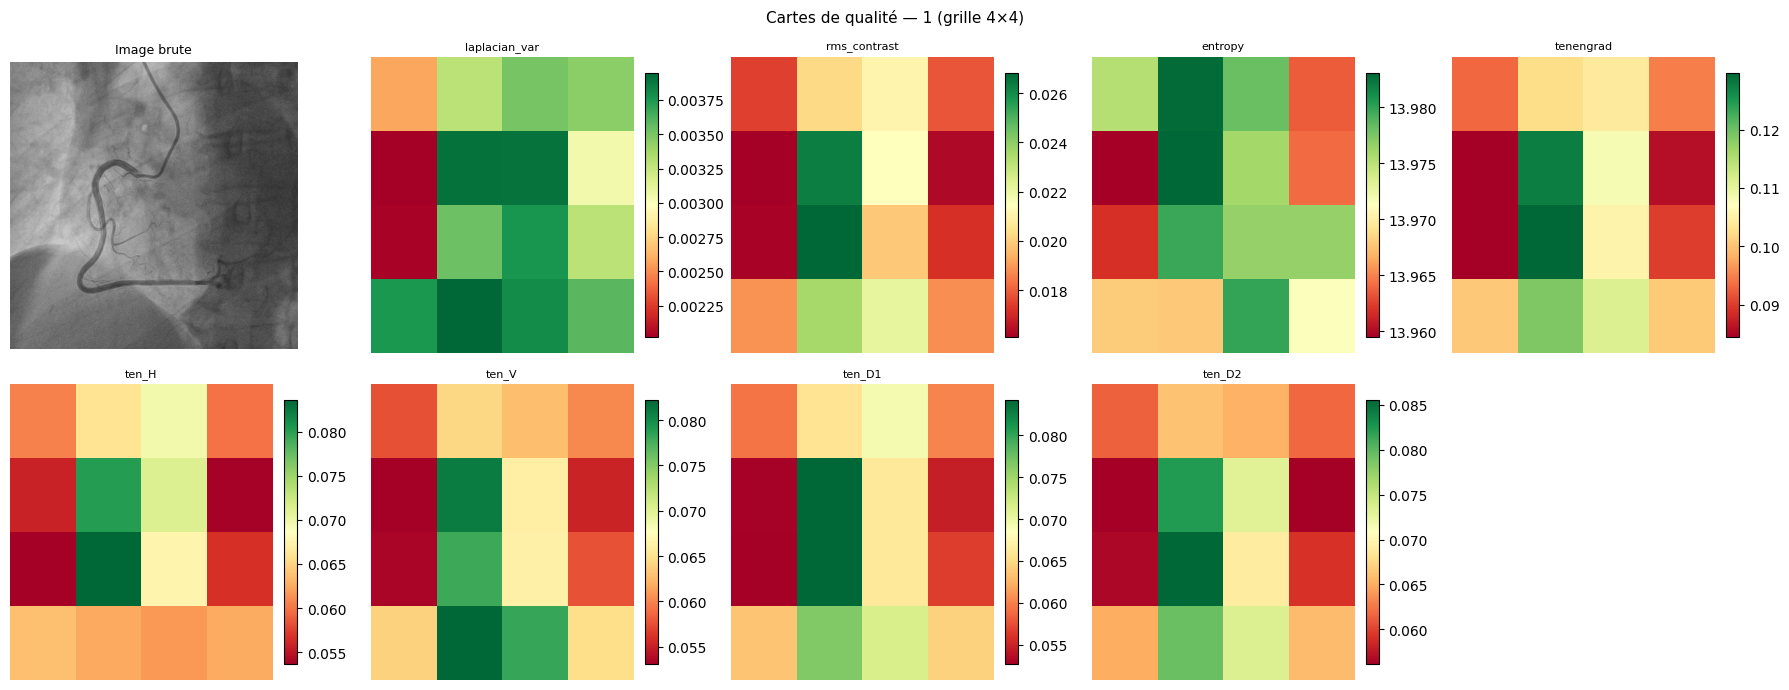

In [22]:
def plot_quality_maps(img_raw: np.ndarray, qmap: np.ndarray, title: str = "", save_path=None):
    n_metrics = len(METRIC_NAMES)
    fig, axes = plt.subplots(2, (n_metrics // 2) + 1, figsize=(18, 7))
    axes = axes.flatten()

    # Image originale
    axes[0].imshow(img_raw, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("Image brute", fontsize=9)
    axes[0].axis("off")

    # Une heatmap par métrique
    for k, name in enumerate(METRIC_NAMES):
        data = qmap[:, :, k]
        ax   = axes[k + 1]
        im   = ax.imshow(data, cmap="RdYlGn", aspect="auto",
                         vmin=np.percentile(data, 5), vmax=np.percentile(data, 95))
        ax.set_title(name, fontsize=8)
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for j in range(n_metrics + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches="tight")
    plt.show()


plot_quality_maps(
    load_gray(all_paths[0]),
    demo_qmap,
    title=f"Cartes de qualité — {all_paths[0].stem} (grille {GRID_SIZE}×{GRID_SIZE})",
    save_path=OUTPUT_DIR / "02_qmap_demo.png",
)

## 8. Analyse directionnelle : la signature d'un flou de mouvement cardiaque

Un artefact de battement cardiaque dégrade principalement la direction **verticale** (le cœur se contracte de haut en bas).  
On visualise la différence de réponse entre les 4 directions pour distinguer les images artefactées des images nettes.

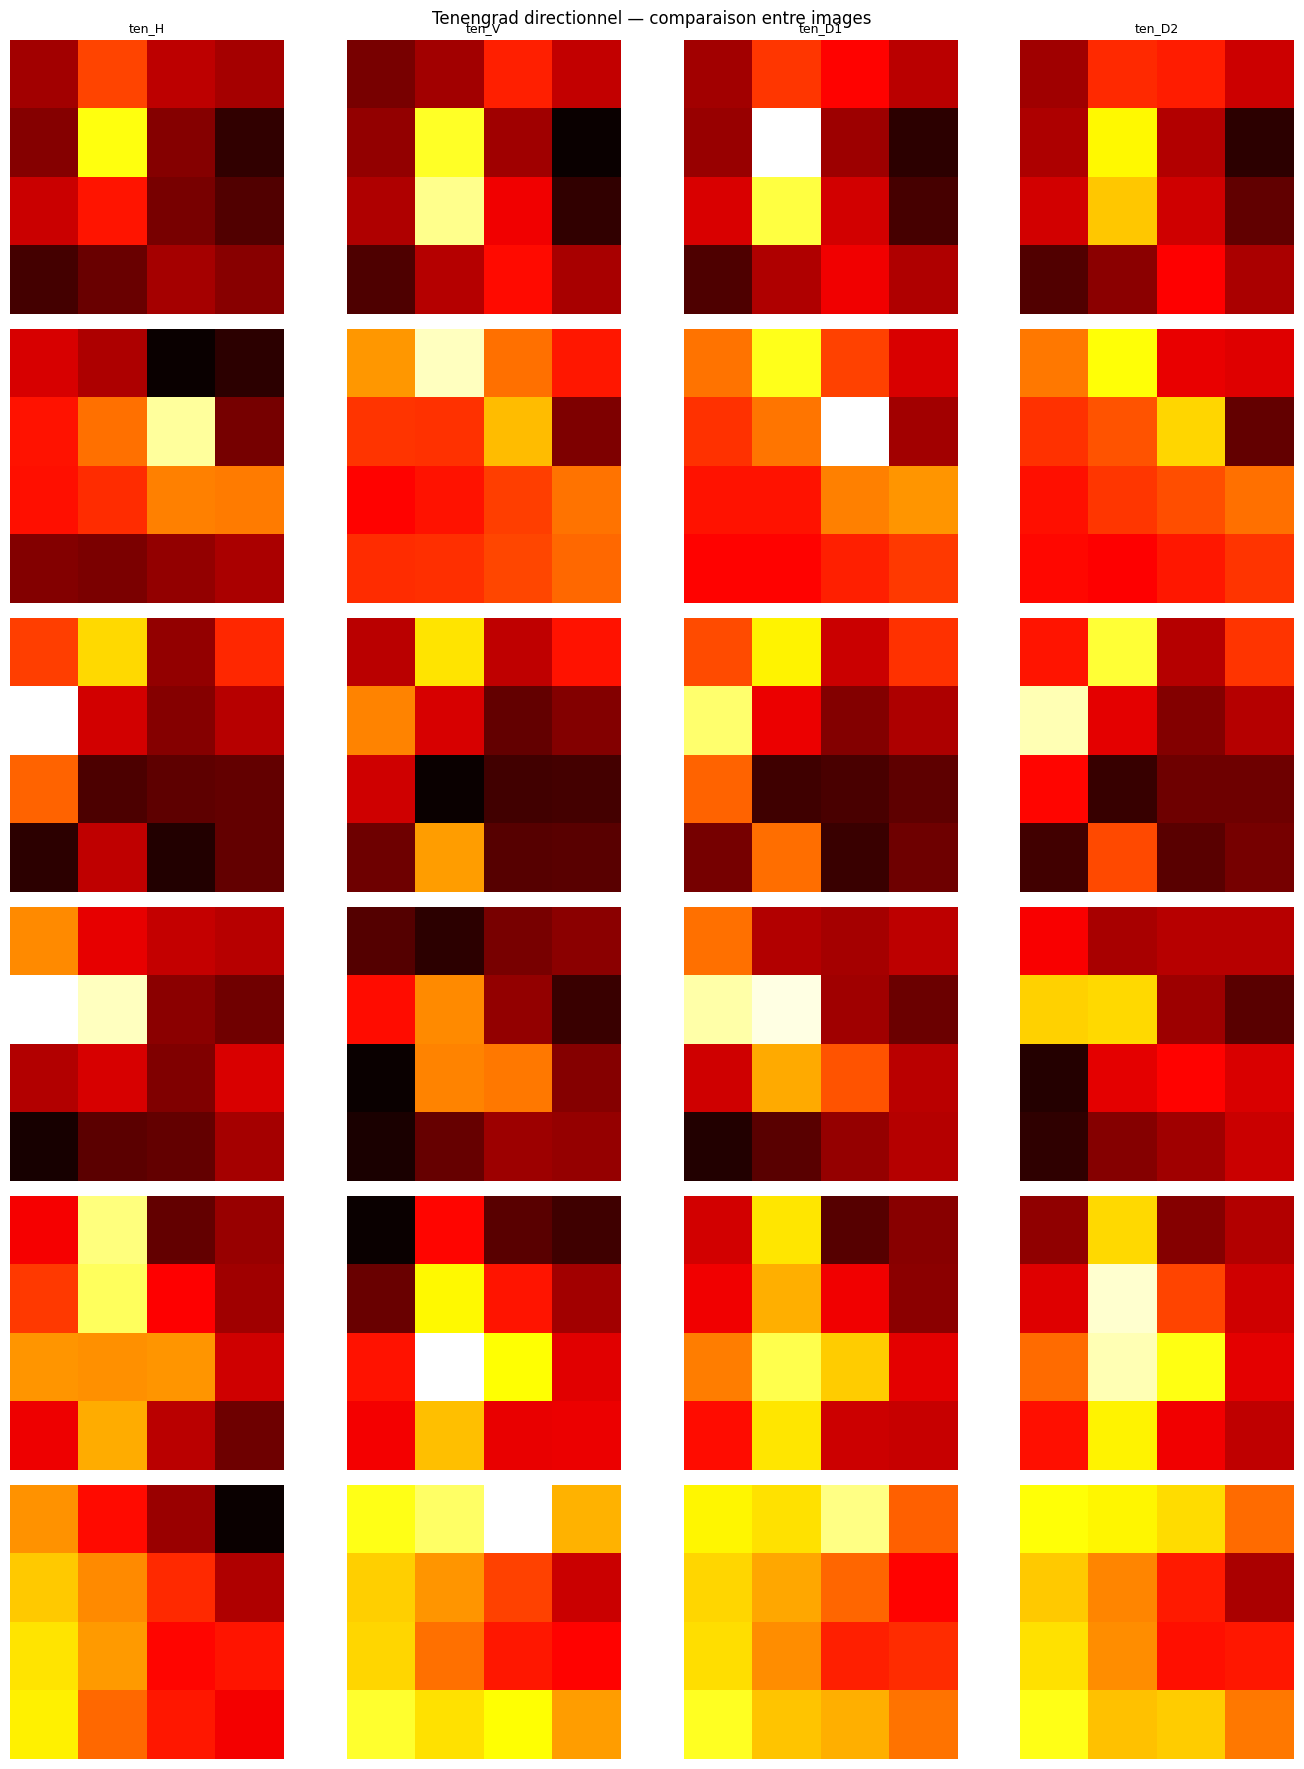

In [23]:
# Charger quelques images variées
demo_paths = random.sample(all_paths, min(6, len(all_paths)))

fig, axes = plt.subplots(len(demo_paths), 4, figsize=(14, 3 * len(demo_paths)))
dir_labels = ["ten_H", "ten_V", "ten_D1", "ten_D2"]
dir_idx    = [4, 5, 6, 7]  # indices dans METRIC_NAMES

for row, path in enumerate(demo_paths):
    img  = mscn_normalize(load_gray(path))
    qmap = compute_quality_map(img)
    vmin = qmap[:, :, dir_idx].min()
    vmax = qmap[:, :, dir_idx].max()

    for col, (label, idx) in enumerate(zip(dir_labels, dir_idx)):
        ax = axes[row, col]
        im = ax.imshow(qmap[:, :, idx], cmap="hot", vmin=vmin, vmax=vmax)
        if row == 0:
            ax.set_title(label, fontsize=9)
        if col == 0:
            ax.set_ylabel(path.stem[:18], fontsize=7)
        ax.axis("off")

fig.suptitle("Tenengrad directionnel — comparaison entre images", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_directional_tenengrad.png", dpi=100, bbox_inches="tight")
plt.show()

## 9. [Optionnel] Extraction de features via ResNet-18

Si les métriques signal-processing ne suffisent pas à discriminer les images,  
on peut utiliser un ResNet-18 pré-entraîné comme **extracteur de texture figé** (aucun fine-tuning nécessaire).

Le vecteur extrait de la couche `AdaptiveAvgPool2d` (dim 512) encode la texture globale de chaque image.  
Ce vecteur pourra servir de biais inductif enrichi pour le cVAE (Notebook 4).

In [24]:
if USE_RESNET:
    import torch
    import torchvision.models as models
    import torchvision.transforms.functional as TF

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Device : {device}")

    resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    # Supprimer la tête de classification, garder jusqu'à AdaptiveAvgPool2d
    feature_extractor = torch.nn.Sequential(*list(resnet.children())[:-1]).to(device).eval()

    print(f"Feature extractor prêt — dim de sortie : 512")
else:
    print("ResNet désactivé (USE_RESNET=False)")

Device : cpu
Feature extractor prêt — dim de sortie : 512


In [25]:
if USE_RESNET:
    def extract_resnet_features(path: Path) -> np.ndarray:
        """
        Retourne un vecteur de features ResNet-18 de dimension 512.
        L'image grayscale est dupliquée sur 3 canaux pour correspondre à l'entrée ResNet.
        """
        img = load_gray(path)  # (H, W) float32
        # → (1, 1, H, W) puis expand vers (1, 3, H, W)
        t = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).expand(-1, 3, -1, -1)
        # Resize à 224×224 (attendu par ResNet)
        t = TF.resize(t, [224, 224])
        # Normalisation ImageNet
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        t    = (t - mean) / std
        with torch.no_grad():
            feat = feature_extractor(t.to(device))  # (1, 512, 1, 1)
        return feat.squeeze().cpu().numpy()  # (512,)

    # Test
    test_feat = extract_resnet_features(all_paths[0])
    print(f"Vecteur features : {test_feat.shape}  — mean={test_feat.mean():.4f}")

Vecteur features : (512,)  — mean=1.1062


## 10. Traitement du dataset complet

On calcule les métriques pour **toutes** les images et on agrège les patchs en scores globaux par image.

In [26]:
def process_one_image(path: Path) -> dict:
    """
    Traite une image et retourne un dict de métriques globales (moyennes sur tous les patchs).
    """
    try:
        img  = mscn_normalize(load_gray(path))
        qmap = compute_quality_map(img)  # (G, G, 8)

        # Agréger par moyenne sur la grille
        global_means = qmap.mean(axis=(0, 1))   # (8,)
        global_stds  = qmap.std(axis=(0, 1))    # (8,)

        record = {"image_id": path.stem, "path": str(path)}
        for k, name in enumerate(METRIC_NAMES):
            record[f"{name}_mean"] = float(global_means[k])
            record[f"{name}_std"]  = float(global_stds[k])

        # Sauvegarder la carte de qualité complète
        np.save(OUTPUT_DIR / "quality_maps" / f"{path.stem}.npy", qmap)

        return record

    except Exception as e:
        return {"image_id": path.stem, "path": str(path), "error": str(e)}


# Traitement en parallèle
records = []
with ThreadPoolExecutor(max_workers=N_WORKERS) as exe:
    futures = {exe.submit(process_one_image, p): p for p in all_paths}
    for future in tqdm(futures, desc="Extraction métriques", total=len(all_paths)):
        records.append(future.result())

df_all = pd.DataFrame(records)
n_errors = df_all["error"].notna().sum() if "error" in df_all.columns else 0
print(f"\nImages traitées : {len(df_all)}  |  Erreurs : {n_errors}")
df_all.head(3)

Extraction métriques: 100%|██████████| 1200/1200 [00:25<00:00, 47.54it/s]


Images traitées : 1200  |  Erreurs : 0


,image_id,path,laplacian_var_mean,laplacian_var_std,rms_contrast_mean,rms_contrast_std,entropy_mean,entropy_std,tenengrad_mean,tenengrad_std,ten_H_mean,ten_H_std,ten_V_mean,ten_V_std,ten_D1_mean,ten_D1_std,ten_D2_mean,ten_D2_std
0,1,C:\Users\theop\Documents\Telecom_Paris\2A\cour...,0.003342,0.000618,0.020089,0.003523,13.972358,0.008451,0.102933,0.014579,0.064917,0.010082,0.065465,0.009941,0.065482,0.009659,0.067891,0.010425
1,10,C:\Users\theop\Documents\Telecom_Paris\2A\cour...,0.002776,0.000380,0.017200,0.000949,13.964206,0.006162,0.092987,0.004844,0.059299,0.004194,0.058691,0.002740,0.059721,0.003356,0.059975,0.003267
2,100,C:\Users\theop\Documents\Telecom_Paris\2A\cour...,0.003954,0.001127,0.020992,0.003521,13.968575,0.014133,0.108084,0.016294,0.069720,0.013283,0.067335,0.008798,0.070237,0.011371,0.069426,0.010992


## 11. Ajout des features ResNet-18 (si activé)

In [27]:
if USE_RESNET:
    print("Extraction features ResNet-18...")
    feat_records = []
    for path in tqdm(all_paths, desc="ResNet features"):
        try:
            feat = extract_resnet_features(path)
            feat_records.append({"image_id": path.stem, "resnet_features": feat})
        except Exception as e:
            feat_records.append({"image_id": path.stem, "resnet_features": None})

    # Sauvegarder séparément (tableau numpy de forme N×512)
    valid   = [(r["image_id"], r["resnet_features"]) for r in feat_records
               if r["resnet_features"] is not None]
    ids_arr  = [v[0] for v in valid]
    feat_arr = np.stack([v[1] for v in valid])  # (N, 512)

    np.save(OUTPUT_DIR / "resnet18_features.npy", feat_arr)
    pd.DataFrame({"image_id": ids_arr}).to_csv(OUTPUT_DIR / "resnet18_ids.csv", index=False)
    print(f"Features sauvegardées : {feat_arr.shape}  → outputs/resnet18_features.npy")
else:
    print("ResNet désactivé.")

Extraction features ResNet-18...


ResNet features: 100%|██████████| 1200/1200 [00:28<00:00, 41.75it/s]

Features sauvegardées : (1200, 512)  → outputs/resnet18_features.npy


## 12. Analyse statistique des scores globaux

In [28]:
mean_cols = [c for c in df_all.columns if c.endswith("_mean")]

print("Statistiques des métriques globales (moyennes sur patchs) :")
print(df_all[mean_cols].describe().round(4))

Statistiques des métriques globales (moyennes sur patchs) :
       laplacian_var_mean  rms_contrast_mean  entropy_mean  tenengrad_mean  \
count           1200.0000          1200.0000     1200.0000       1200.0000   
mean               0.0032             0.0225       13.7642          0.1028   
std                0.0017             0.0066        0.8567          0.0234   
min                0.0002             0.0087        6.9072          0.0430   
25%                0.0021             0.0171       13.9410          0.0882   
50%                0.0027             0.0205       13.9591          0.1020   
75%                0.0039             0.0282       13.9689          0.1176   
max                0.0093             0.0448       13.9860          0.1813   

       ten_H_mean  ten_V_mean  ten_D1_mean  ten_D2_mean  
count   1200.0000   1200.0000    1200.0000    1200.0000  
mean       0.0639      0.0644       0.0680       0.0672  
std        0.0142      0.0142       0.0161       0.0158  
min  

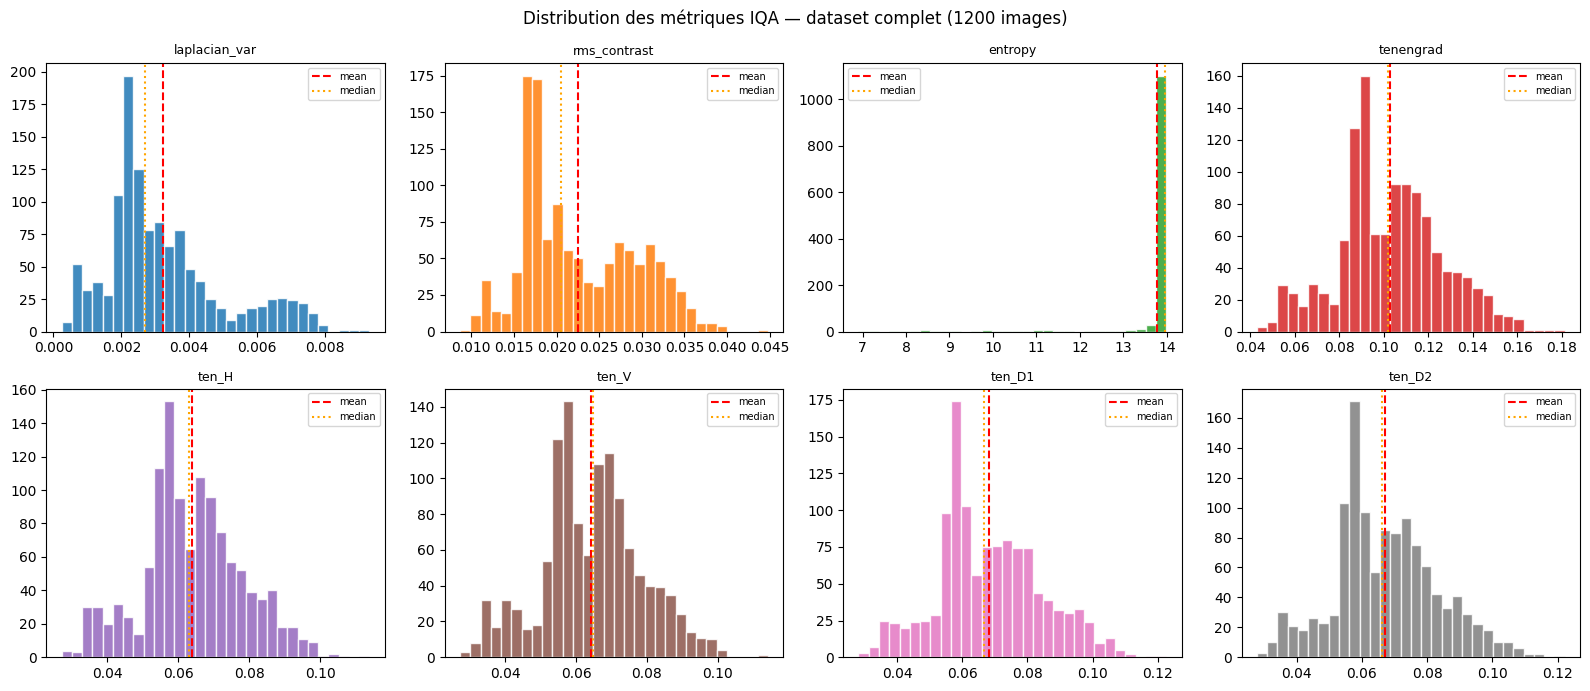

In [29]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

colors = plt.cm.tab10.colors
for k, (col, ax) in enumerate(zip(mean_cols, axes)):
    data = df_all[col].dropna()
    ax.hist(data, bins=30, color=colors[k % 10], edgecolor="white", alpha=0.85)
    ax.axvline(data.mean(),   color="red",    lw=1.5, ls="--", label="mean")
    ax.axvline(data.median(), color="orange", lw=1.5, ls=":",  label="median")
    ax.set_title(col.replace("_mean", ""), fontsize=9)
    ax.legend(fontsize=7)

for j in range(len(mean_cols), len(axes)):
    axes[j].axis("off")

fig.suptitle(f"Distribution des métriques IQA — dataset complet ({len(df_all)} images)", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_full_dataset_distributions.png", dpi=100, bbox_inches="tight")
plt.show()

## 13. Corrélations entre métriques

On vérifie quelles métriques sont redondantes et lesquelles apportent une information orthogonale.

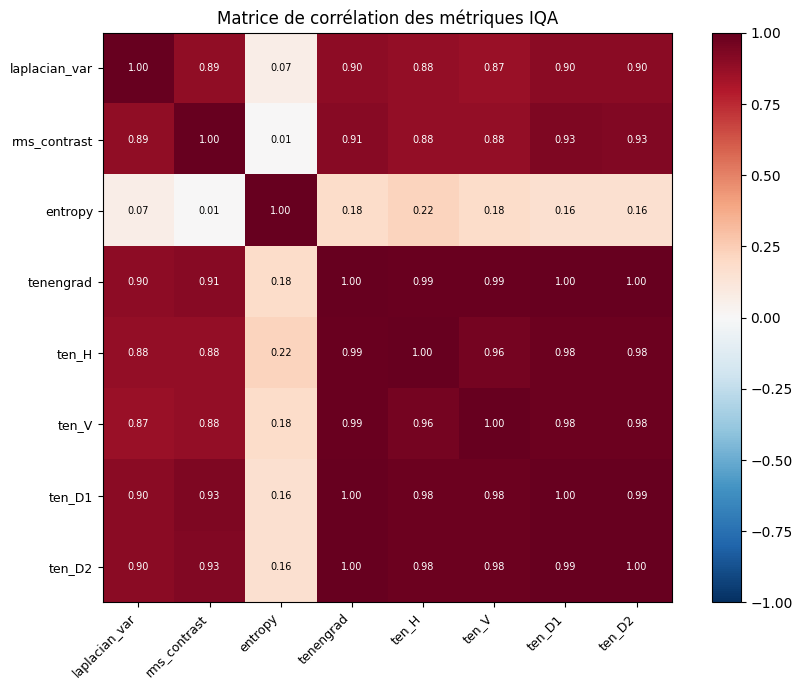

In [30]:
corr = df_all[mean_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

labels = [c.replace("_mean", "") for c in mean_cols]
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(labels, fontsize=9)

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center",
                fontsize=7, color="black" if abs(corr.values[i, j]) < 0.7 else "white")

ax.set_title("Matrice de corrélation des métriques IQA", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_correlation_matrix.png", dpi=100, bbox_inches="tight")
plt.show()

## 14. Top images good / bad selon Tenengrad

On identifie les images extrêmes pour alimenter le Notebook 3 (label manuel de validation).

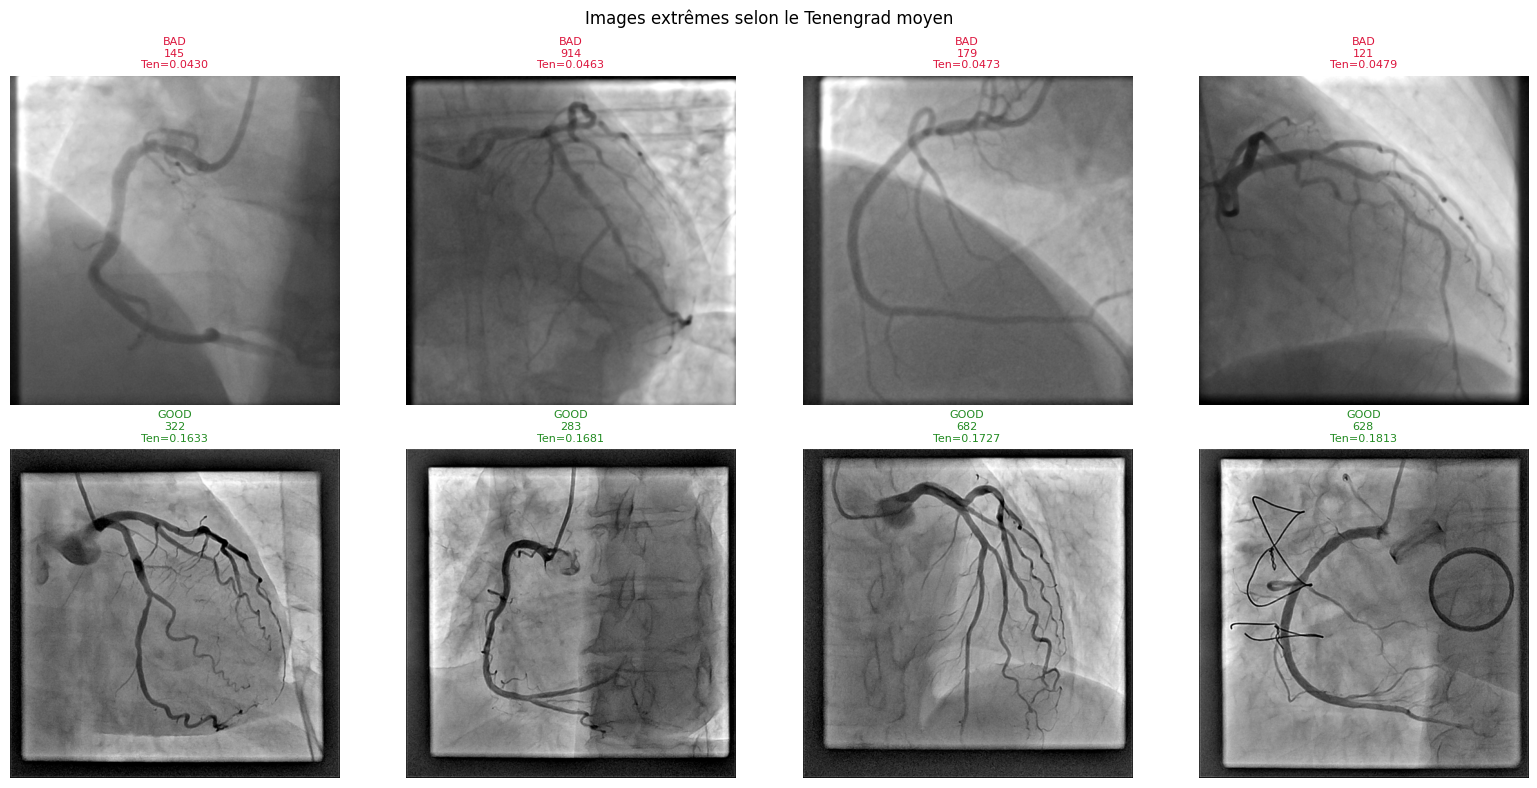

In [31]:
df_sorted = df_all.dropna(subset=["tenengrad_mean"]).sort_values("tenengrad_mean")

n_show = 4
worst_paths = [Path(p) for p in df_sorted["path"].head(n_show)]
best_paths  = [Path(p) for p in df_sorted["path"].tail(n_show)]

fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 8))

for col, (path, score) in enumerate(
    zip(worst_paths, df_sorted["tenengrad_mean"].head(n_show))
):
    axes[0, col].imshow(load_gray(path), cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(f"BAD\n{path.stem}\nTen={score:.4f}", color="crimson", fontsize=8)
    axes[0, col].axis("off")

for col, (path, score) in enumerate(
    zip(best_paths, df_sorted["tenengrad_mean"].tail(n_show))
):
    axes[1, col].imshow(load_gray(path), cmap="gray", vmin=0, vmax=1)
    axes[1, col].set_title(f"GOOD\n{path.stem}\nTen={score:.4f}", color="forestgreen", fontsize=8)
    axes[1, col].axis("off")

fig.suptitle("Images extrêmes selon le Tenengrad moyen", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_extreme_images.png", dpi=120, bbox_inches="tight")
plt.show()

## 15. Export final

In [32]:
out_csv = OUTPUT_DIR / "patch_metrics_full.csv"
df_all.drop(columns=["error"], errors="ignore").to_csv(out_csv, index=False)
print(f"Sauvegardé → {out_csv}")
print(f"Colonnes : {list(df_all.columns)}")
print(f"Cartes de qualité .npy → {OUTPUT_DIR / 'quality_maps'}/ ({len(list((OUTPUT_DIR / 'quality_maps').glob('*.npy')))} fichiers)")

Sauvegardé → outputs\patch_metrics_full.csv
Colonnes : ['image_id', 'path', 'laplacian_var_mean', 'laplacian_var_std', 'rms_contrast_mean', 'rms_contrast_std', 'entropy_mean', 'entropy_std', 'tenengrad_mean', 'tenengrad_std', 'ten_H_mean', 'ten_H_std', 'ten_V_mean', 'ten_V_std', 'ten_D1_mean', 'ten_D1_std', 'ten_D2_mean', 'ten_D2_std']
Cartes de qualité .npy → outputs\quality_maps/ (1000 fichiers)


## Résumé du Notebook 2

| Étape | Résultat |
|---|---|
| Extraction de patchs | Grille `GRID_SIZE×GRID_SIZE` par image |
| 8 métriques par patch | Laplacian, RMS, Entropie, Tenengrad (global + 4 directions) |
| Carte de qualité 2D | `(G, G, 8)` par image — sauvegardée en `.npy` |
| Corrélations | Matrice pour identifier les métriques orthogonales |
| Feature ResNet-18 | Vecteur 512D optionnel — `resnet18_features.npy` |
| Export CSV | `outputs/patch_metrics_full.csv` |

**Prochain notebook :** `03_Inductive_Bias_Generation.ipynb` — agrégation des métriques en un score unique $c \in [0, 1]$ via PCA ou normalisation Min-Max, et export de `labels_quality.csv`.